# 9. Arequipa, the full DEM

Every number this project has published comes from **crops** — Colca, and small Arequipa
windows. The full DEM is the run that has never been done, and this notebook is where it
lands.

[Notebook 8](08_explaining_a_run.ipynb) covers how to drive the pipeline and how to read
what it says. This one is about one specific run, at a scale the crops cannot speak
for.

In [1]:
import json
import os

from oroscope import explain

**Read, not run.** The cells below open results that were produced locally and stored in
`results/arequipa_full/`. They do not start a search. Each of these searches takes about
half an hour, CI executes notebooks on every push, and a tutorial costing ninety minutes
of compute per commit is a bill rather than a tutorial. The expensive half runs once, on
a machine that has the DEM; the notebook opens a few hundred kilobytes of JSON.

To produce or refresh the store:

```bash
python tools/run_full_dem.py --dry-run   # report the cost, then stop
python tools/run_full_dem.py             # GRAND, TAMBO, then the combination
```

**Start with `--dry-run`.** It begins nothing — no search, no file, no change to the
store — and prints the five things worth knowing before committing an hour of a
machine:

```text
DEM:       input/dem/arequipa_SRTMGL1.tif
estimate:  5.08 GiB at downsample_factor 4
available: 6.4 GiB
would run: grand, tambo, then combine
expected:  ~25 min for grand, ~1 min for tambo
store:     results/arequipa_full
```

`DEM` says whether the file is even present, so a missing DEM is reported before the
first search starts rather than after. `estimate` against `available` is what decides
`downsample_factor` and `candidate_stride` — the same DEM needs 7.2 GiB at 1 and
5.1 GiB at 4, and downsampling helps less than it looks because the candidates are taken
on the native grid regardless. `would run` honours `--only`, so `--only grand` runs one
search and skips the combination. And no memory cap is applied during a dry run, because
nothing is allocated.

**This is a run that needs its cap set.** The default ceiling is 80% of what the system
reports available, which on a machine whose desktop already holds half of RAM is below
what the search needs: the first attempt died 23 minutes in, at the scoring stage,
against a 5.5 GiB cap. Pass `--max-memory-gb` explicitly — the run measured 5.68 GiB
peak RSS.

**Regenerate it when a configuration changes, and not otherwise.** The store carries a
manifest naming the configs and the time, so a stale one is detectable rather than
merely suspected.

Three searches, all at the same `downsample_factor` so their masks are pixel-aligned:

| | config | what it asks |
|---|---|---|
| **GRAND alone** | `config/grand_arequipa_full.json` | 3–25° deployable ground seeing a target 10–40 km away, within ±3° of the horizon |
| **TAMBO alone** | `config/tambo_arequipa_full.json` | a 20–60° near wall facing a ≥25° far wall, 2–5 km across |
| **Combined** | `combine_experiments` over both | joint, union, and how much of each sits inside the other |

**What it costs.** 10204 × 12603 pixels, about 129 Mpx. At `downsample_factor: 4` the
estimator says 5.1 GiB against the ~6–7 GiB typically free; at 1 it says 7.2 GiB, which
is why 4 is the setting. That choice has a price worth stating: area is measured on the
downsampled mask while capacity is measured at full resolution, so a feature a few
pixels wide keeps its detectors and loses area — the run puts it at around 30% for a
canyon strip. **Read these areas as lower bounds**, and more so for TAMBO's canyon
strips than for GRAND's blobs. It is the reason TAMBO's full-DEM area below cannot be
compared directly against the crop's, which was measured at `downsample_factor: 1`.

In [2]:
STORE = os.path.abspath(os.path.join("..", "results", "arequipa_full"))

def load_stored(label):
    """Reads one stored run, or returns None when the store does not have it yet."""
    path = os.path.join(STORE, f"{label}_results.json")
    if not os.path.exists(path):
        return None
    with open(path) as f:
        return json.load(f)

manifest_path = os.path.join(STORE, "manifest.json")
if os.path.exists(manifest_path):
    with open(manifest_path) as f:
        manifest = json.load(f)
    print(f"store generated {manifest['generated']} by {manifest['generated_by']}")
    print(f"from {manifest['dem']}\n")
    for name in manifest["files"]:
        print("   ", name)
else:
    manifest = None
    print("The full-DEM store is empty: these searches have not been run yet.\n")
    print("Produce it with:")
    print("    python tools/run_full_dem.py --dry-run")
    print("    python tools/run_full_dem.py")

grand_full = load_stored("grand")
tambo_full = load_stored("tambo")

store generated 2026-08-16T22:28:58 by tools/run_full_dem.py
from input/dem/arequipa_SRTMGL1.tif

    tambo_explanation.txt
    tambo_provenance.json
    tambo_results.json


### GRAND over the whole DEM

The four things worth reading, in this order:

1. **The funnel**, and specifically whether the binding constraint is the same one the
   crops found. If a full DEM is bound by a different stage than its crops were, the
   crops were not representative and every number derived from them needs re-reading.
2. **The area**, against the crop scaled up — and against the closing factor this run
   reports for itself, rather than the 2.29× quoted from Colca.
3. **The site count and their spread.** A crop cannot say whether the good ground is one
   region or fifty scattered ones, and that is a deployment question, not a physics one.
4. **The weakest score component**, which on the crops is `solid_angle` everywhere. If
   that holds at full scale it is a statement about the criterion, not about Peru.

In [3]:
def summarise(results, label):
    if results is None:
        print(f"{label}: not in the store yet.")
        return
    chosen, shortlisted = explain.selected_sites(results)
    area = sum(s["area_km2"] for s in chosen)
    binding = explain.binding_constraint(results["funnel"])
    ratio = explain.closing_inflation(results["funnel"],
                                      results["parameters"]["candidate_stride"])
    weakest = [explain.weakest_component(s.get("arrival_scan") or {}) for s in chosen]
    named = [w[0] for w in weakest if w]

    print(f"{label}")
    print(f"   sites          {results['results']['total_sites']:>10,}"
          f"   ({len(shortlisted)} more cleared the thresholds, not selected)")
    print(f"   capacity       {results['results']['total_capacity']:>10,}")
    print(f"   area           {area:>10,.1f} km²")
    if binding:
        print(f"   bound by       {binding['stage']}"
              f"  (kept {100*binding['kept_fraction']:.1f}%)")
    if ratio is not None:
        print(f"   closing moved  {ratio:>10.2f}x")
    if named:
        commonest = max(set(named), key=named.count)
        print(f"   weakest        {commonest} at {named.count(commonest)}/{len(named)} sites")

summarise(grand_full, "GRAND, full Arequipa DEM")

GRAND, full Arequipa DEM
   sites                   1   (0 more cleared the thresholds, not selected)
   capacity          101,948
   area             88,527.5 km²
   bound by       directions accepted  (kept 61.6%)
   closing moved        2.10x
   weakest        solid_angle at 1/1 sites


In [4]:
if grand_full is not None:
    print(grand_full.get("explanation") or explain.explain_results(grand_full))
else:
    print("Nothing stored for GRAND yet -- see the cell above for how to produce it.")

 WHAT THIS SEARCH FOUND, AND WHY

THE RUN
-------
  DEM              /home/mbustamante/Research/GRAND/oroscope/input/dem/arequipa_SRTMGL1.tif
  Origin           -14.555139, -73.586250  (auto-detected from the GeoTIFF tiepoint)
  Resolution       0.00027778°/px  =  30.7 m N-S x 29.7 m E-W
  Layout           distributed search, hex grid, 1.0 km spacing
  Finished         2026-08-16 07:46:53

THE HEADLINE
------------
  1 site covering 88,527.5 km², 101,948 detectors against a target of 10,000.

  Largest by capacity: site 1, 88,527.51 km², 101,948 detectors, facing S,
  centred -15.7886, -71.6611 — paste that into a map.

WHERE THE CANDIDATES WENT
-------------------------
  stage                           |         pixels |   of DEM |  of prev
  ----------------------------------------------------------------------
  DEM pixels                      |    128,601,012 | 100.000% |         -
  finite elevation                |    125,642,792 |  97.700% |  97.700%
  slope 3.0-25.0 deg       

### TAMBO over the whole DEM

The more interesting of the two, because TAMBO's criteria are canyon-shaped and the
crop was *chosen* for containing a canyon. Over the whole DEM the question becomes: how
much other canyon is there, and is any of it as good?

Note that the areas here are the ones most affected by `downsample_factor: 4`: a strip
along a wall is exactly the feature that loses area to downsampling while keeping its
detectors.

In [5]:
summarise(tambo_full, "TAMBO, full Arequipa DEM")

TAMBO, full Arequipa DEM
   sites                  85   (0 more cleared the thresholds, not selected)
   capacity           47,136
   area                991.6 km²
   bound by       score >= 0.35  (kept 11.0%)
   closing moved        0.96x
   weakest        solid_angle at 85/85 sites


In [6]:
if tambo_full is not None:
    print(tambo_full.get("explanation") or explain.explain_results(tambo_full))
else:
    print("Nothing stored for TAMBO yet -- see above for how to produce it.")

 WHAT THIS SEARCH FOUND, AND WHY

THE RUN
-------
  DEM              /home/mbustamante/Research/GRAND/oroscope/input/dem/arequipa_SRTMGL1.tif
  Origin           -14.555139, -73.586250  (auto-detected from the GeoTIFF tiepoint)
  Resolution       0.00027778°/px  =  30.7 m N-S x 29.7 m E-W
  Layout           distributed search, hex grid, 0.15 km spacing
  Finished         2026-08-16 22:28:58

THE HEADLINE
------------
  85 sites covering 991.6 km² between them, 47,136 detectors against a target
  of 5,000.

  Largest by capacity: site 2243, 59.43 km², 2,910 detectors, facing W,
  centred -16.1166, -73.1494 — paste that into a map.

WHERE THE CANDIDATES WENT
-------------------------
  stage                           |         pixels |   of DEM |  of prev
  ----------------------------------------------------------------------
  DEM pixels                      |    128,601,012 | 100.000% |         -
  finite elevation                |    125,642,792 |  97.700% |  97.700%
  slope 20.0-60.0

### Where both are viable

The overlay. On the Colca crop the answer was decided by slope: GRAND's 3–25° deployable
band against Colca's ~40° walls leaves only a 20–25° sliver, so the joint was about a
percent of GRAND's area and three fifths of TAMBO's.

Whether that survives at full scale is a real question. The crop contains one canyon
system; the DEM contains many, of varying wall slope, and the joint area is the
programme-level number — one site, one road, one power feed, two experiments.

In [7]:
report_path = os.path.join(STORE, "combined_report.json")
if not os.path.exists(report_path):
    print("The combination has not been produced yet.")
else:
    with open(report_path) as f:
        report = json.load(f)

    width = max(len(r["label"]) for r in report["runs"])
    print(f"   {'experiment'.ljust(width)} {'area km²':>12} {'sites':>7} "
          f"{'capacity':>10} {'in joint':>9}")
    print("   " + "-" * (width + 42))
    for r in report["runs"]:
        print(f"   {r['label'].ljust(width)} {r['area_km2']:>12,.1f} "
              f"{r['reported_sites']:>7,} {r['reported_capacity']:>10,} "
              f"{100*r['fraction_of_own_area_in_joint']:>8.1f}%")
    print("   " + "-" * (width + 42))
    print(f"   joint  {report['joint']['area_km2']:>10,.1f} km²")
    print(f"   union  {report['union']['area_km2']:>10,.1f} km²")
    for pair, stats in report["pairwise_overlap"].items():
        print(f"   {pair}: Jaccard {stats['jaccard']:.4f}")

   experiment     area km²   sites   capacity  in joint
   -----------------------------------------------
   GRAND     88,527.5       1    101,948      0.7%
   TAMBO        991.5      85     47,136     60.3%
   -----------------------------------------------
   joint       597.9 km²
   union    88,921.1 km²
   GRAND & TAMBO: Jaccard 0.0067


And the overlay explains itself too, the same way a search does — including the part
that is easy to get wrong. Co-location is decided by whichever *ground* property the
two experiments share least of, because a pixel has one slope and both have to accept
it. What each asks of the **view** — the distance window, the arrival elevations — may
differ freely: two experiments can look out from the same hillside at different ranges
without conflict.

`oroscope-combine` prints this and saves it as `combination_explanation.txt`.

In [8]:
if not os.path.exists(report_path):
    print("The combination has not been produced yet.")
else:
    runs = {label: res for label, res in (("GRAND", grand_full), ("TAMBO", tambo_full))
            if res is not None}
    print(explain.explain_combination(report, runs))

 WHERE THESE EXPERIMENTS CAN SHARE GROUND, AND WHY

WHAT EACH BRINGS
----------------
  experiment |     area km² |   sites |  detectors |  in joint
  ----------------------------------------------------------
  GRAND      |     88,527.5 |       1 |    101,948 |      0.7%
  TAMBO      |        991.5 |      85 |     47,136 |     60.3%

  Ground satisfying GRAND and TAMBO at once: 597.9 km². Ground useful to any
  of them: 88,921.1 km². The first is the number that matters for one site,
  one road and one power feed serving two experiments; the second is what the
  programme as a whole could use.

WHAT DECIDES IT
---------------
  A pixel has one slope, one altitude and one aspect, and both experiments
  must accept those same values to stand on it. So co-location is settled by
  whichever of those bands they share least of — before any arrival geometry
  is considered.

  band               |            GRAND |            TAMBO | shared
  ------------------------------------------------

### Comparing against the crop

The crop's numbers, for reference — GRAND 4580.2 km² in 1 site with 5317 detectors,
TAMBO 83.6 km² in 15 sites with 9717, joint 50.1 km². If the full DEM's binding
constraint or weakest component differs from these, the crop was not representative and
the comparison is the finding.

A crop is chosen because it is interesting. **A search over ground chosen for being
interesting is not a survey**, and that is the gap this run exists to close.

In [9]:
if grand_full is not None and tambo_full is not None:
    print("Both full-DEM runs are stored; compare their funnels against the crops':\n")
    for label, res in (("GRAND", grand_full), ("TAMBO", tambo_full)):
        b = explain.binding_constraint(res["funnel"])
        print(f"   {label:>6}: bound by {b['stage']!r} "
              f"(kept {100*b['kept_fraction']:.1f}%)")
    print("\n   Colca crop, for comparison:")
    print("   GRAND: bound by 'directions accepted' (kept 60.1%)")
    print("   TAMBO: bound by 'directions accepted' (kept 17.5%)")
else:
    print("Run both searches to make this comparison.")

Both full-DEM runs are stored; compare their funnels against the crops':

    GRAND: bound by 'directions accepted' (kept 61.6%)
    TAMBO: bound by 'score >= 0.35' (kept 11.0%)

   Colca crop, for comparison:
   GRAND: bound by 'directions accepted' (kept 60.1%)
   TAMBO: bound by 'directions accepted' (kept 17.5%)


### The maps

The store holds the numbers, not the rasters — a GeoTIFF of a 129 Mpx mask is far too
large for a repository. But the PNG maps are in `output/`, and if you have run the
searches locally they are worth looking at rather than reading about: the funnel says
*how much* ground survived, the map says *where* it is.

If `output/` is empty here, produce it with `python tools/run_full_dem.py`. The
images below are stored in this notebook, so they are visible either way.

In [10]:
from IPython.display import Image, display


def show_figure(path, width=1100, caption=None):
    """Displays a figure the pipeline wrote, downscaled so the notebook stays small.

    The searcher saves its map to disk and says where; a notebook that only prints the
    path makes the reader go and find it. Downscaled because the full-resolution PNG is
    a megabyte or two and these outputs are committed.
    """
    if not os.path.exists(path):
        print(f"not here yet: {os.path.relpath(path)}")
        return
    try:
        from PIL import Image as PILImage
        import io as _io
        img = PILImage.open(path)
        if img.width > width:
            img = img.resize((width, round(img.height * width / img.width)),
                             PILImage.LANCZOS)
        buf = _io.BytesIO()
        img.convert("RGB").save(buf, format="PNG", optimize=True)
        data = buf.getvalue()
        # A shaded terrain map is photographic and does not compress as PNG: the full
        # Arequipa map is 1.1 MB at this width and 190 KB as JPEG, for no visible
        # difference. Line art stays PNG, where JPEG would ring around every edge.
        if len(data) > 250 * 1024:
            jpg = _io.BytesIO()
            img.convert("RGB").save(jpg, format="JPEG", quality=82, optimize=True)
            data = jpg.getvalue()
    except Exception:                       # pillow absent: show it full size
        with open(path, "rb") as f:
            data = f.read()
    if caption:
        print(caption)
    display(Image(data=data))

GRAND over the full Arequipa DEM


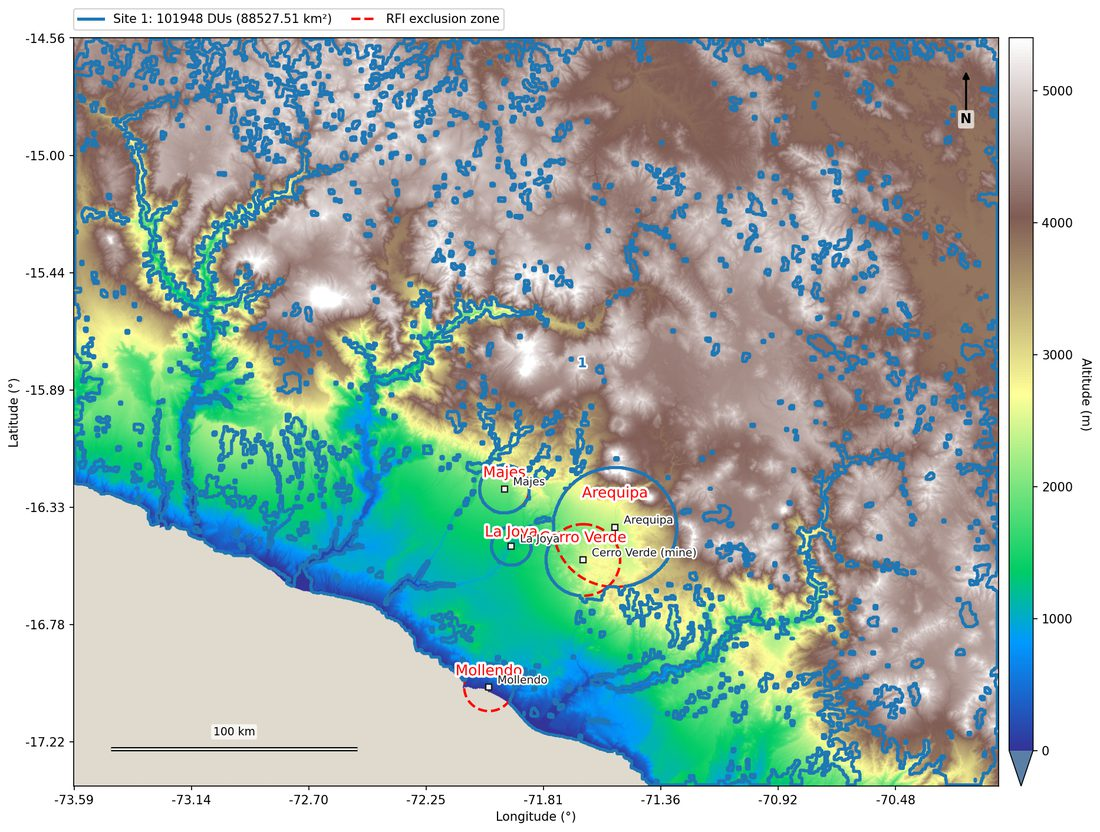

TAMBO over the full Arequipa DEM


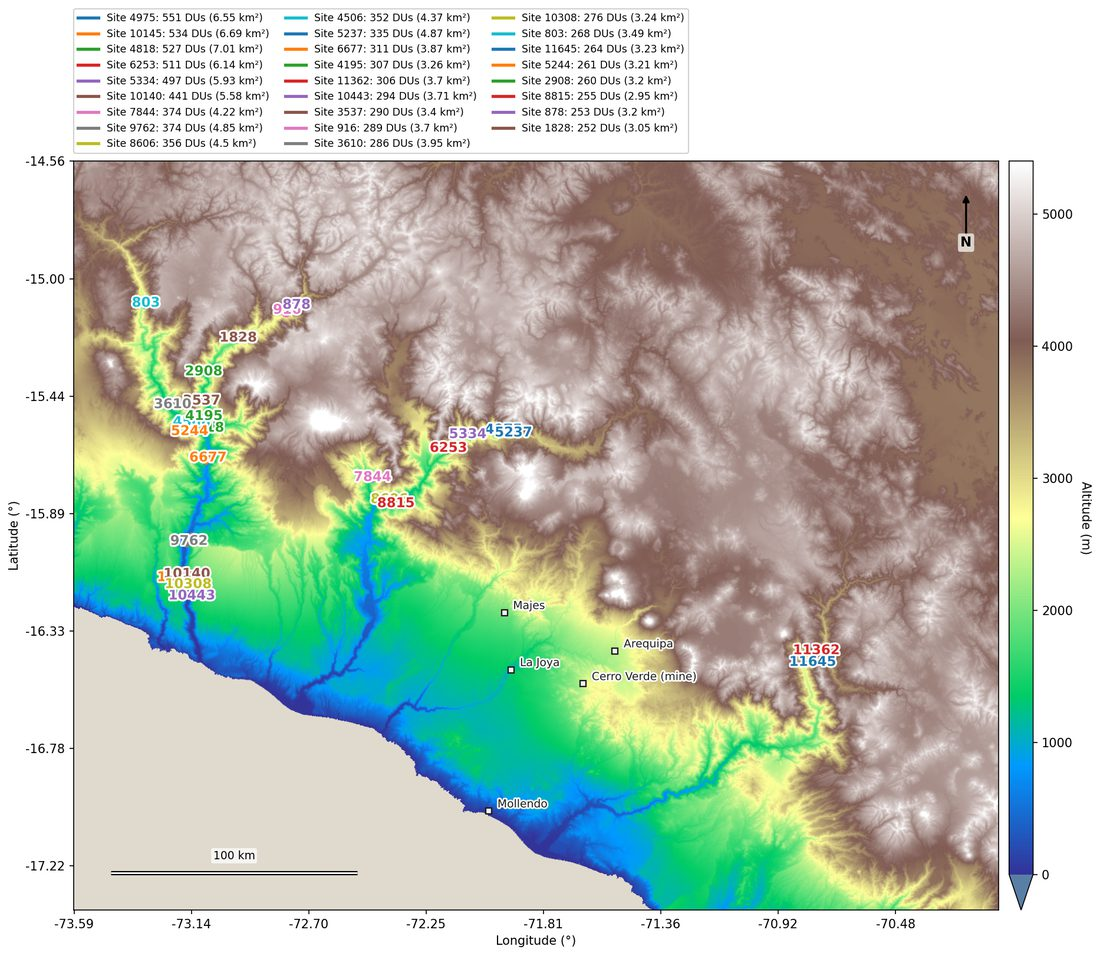

In [11]:
import glob

OUT = os.path.abspath(os.path.join("..", "output"))
for label, folder in (("GRAND", "arequipa_full_grand"),
                      ("TAMBO", "arequipa_full_tambo")):
    found = sorted(glob.glob(os.path.join(OUT, folder, "oroscope_results*.png")))
    show_figure(found[0] if found else os.path.join(OUT, folder, "none.png"),
                caption=f"{label} over the full Arequipa DEM")

### The overlay, one experiment at a time

The combination is easier to read built up than all at once, so `--reveal` writes it as
three frames. Everything that is not a category — the terrain, the colour bar, the
roads, the towns, the scale bar, the legend — is identical in all three, so what
changes between them is only the result.

**First GRAND alone.** It is *outlined* rather than filled: it covers most of the
frame, and a translucent wash over that much of a map hides everything underneath.
Notice where the boundary runs — GRAND's constraint is deployable slope, so it accepts
the high plateau and declines the canyon walls and the steep coast.

GRAND alone — 88,527 km², essentially the whole plateau


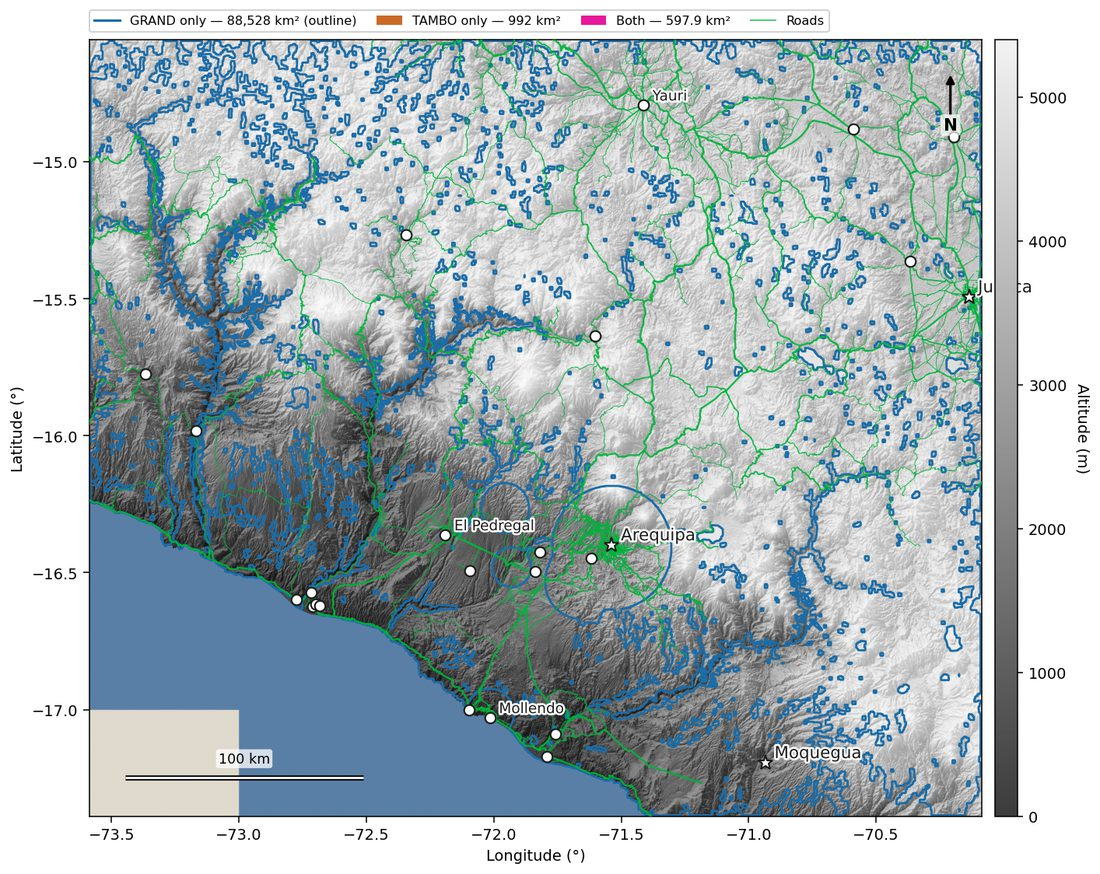

In [12]:
def show_stage(name, caption):
    found = os.path.join(OUT, "arequipa_full_combined", name)
    show_figure(found, caption=caption)

show_stage("combined_overview_1_grand.png",
           "GRAND alone — 88,527 km², essentially the whole plateau")

**Now TAMBO alone.** A different question entirely, and it shows: instead of a
boundary enclosing most of the map, a scatter of small patches strung along the canyon
systems. TAMBO needs a wall to stand on facing a wall to watch, and that exists only
where the ground is cut.

TAMBO alone — 112 km², following the canyons


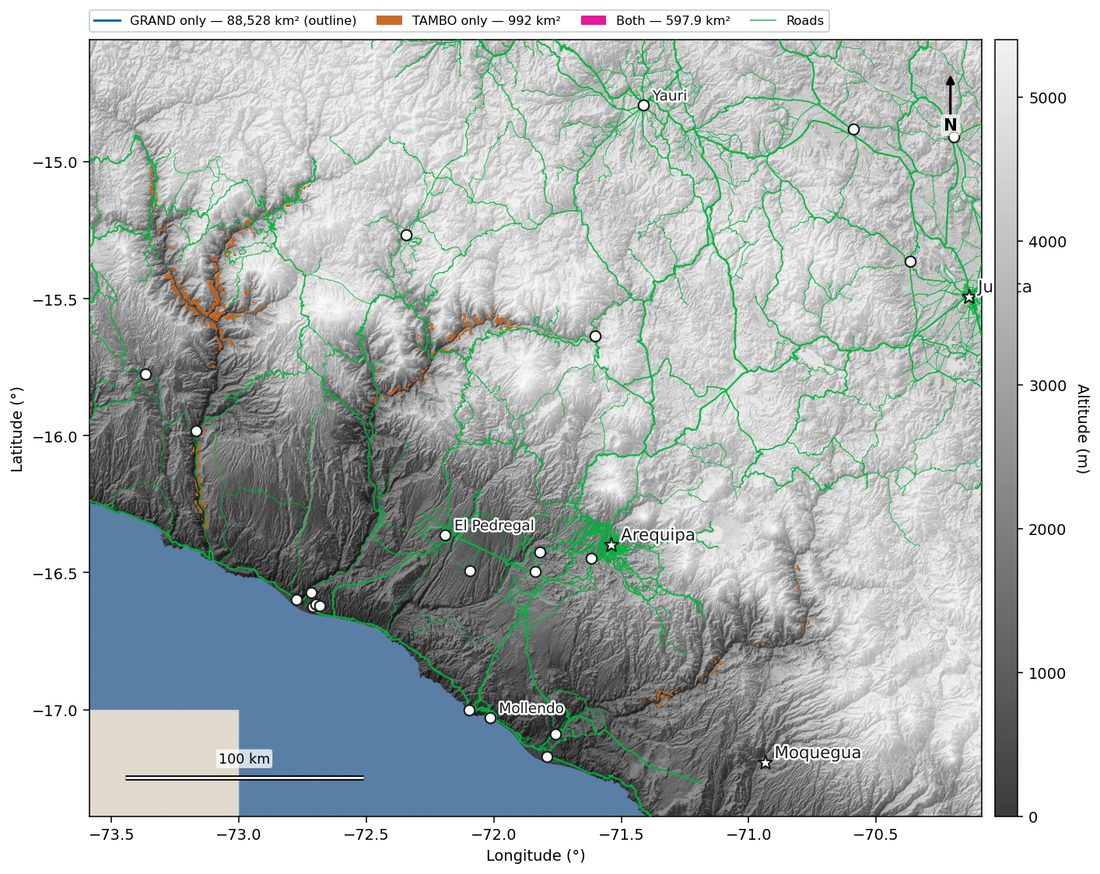

In [13]:
show_stage("combined_overview_2_tambo.png",
           "TAMBO alone — 112 km², following the canyons")

**And both.** The magenta is the ground that satisfies the two at once: 50.2 km²,
0.1% of GRAND's and 44.9% of TAMBO's. The asymmetry is the finding — co-location costs
GRAND nothing and is most of what TAMBO has.

Look at where the magenta *is*. It traces the canyon rims, and the roads run along them
too, which is not a coincidence: a canyon rim is where a road goes in this terrain.

Both — the 50.2 km² that satisfies GRAND and TAMBO together


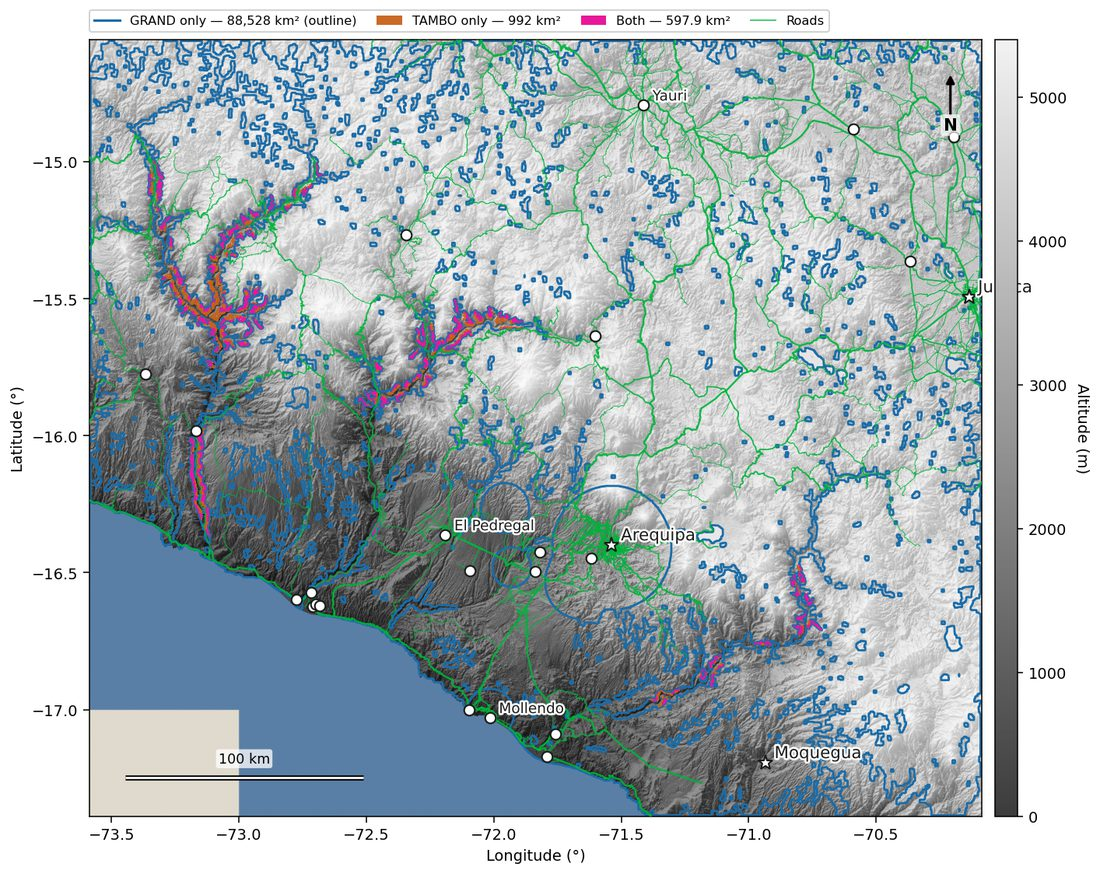

In [14]:
show_stage("combined_overview_3_both.png",
           "Both — the 50.2 km² that satisfies GRAND and TAMBO together")

## What moves the answer

The numbers above come from one setting of every parameter. The honest question is how
much they would move under another, and that cannot be read off a single run.

The full DEM is far too slow to sweep — GRAND alone is 25 minutes a point — so what
follows searches a **small synthetic canyon** instead: a plateau cut by a gorge, a few
hundred pixels across, seconds per run. The absolute numbers mean nothing. The
*direction and steepness* of each response is the point, and those carry over.

In [15]:
import contextlib
import io
import tempfile

import numpy as np
import tifffile as tiff

from oroscope import site_searcher as ss

WORK = tempfile.mkdtemp(prefix="oroscope_nb08_")


def plateau_with_canyon(n=400, depth_m=1300.0, floor_px=30, wall_px=35):
    """
    A high plateau cut by a gorge: ground a canyon search has an opinion about.

    Sized against the criteria rather than drawn freehand. At ~30 m pixels the rim-to-
    rim distance is 3.0 km, so the far wall sits inside a 1-4 km window, and the walls
    are ~51 deg, inside the 20-60 deg band. A narrower or steeper canyon returns
    nothing at all, which is a lesson about the criteria but a poor demonstration.
    """
    col = np.arange(n)
    wall = np.clip((np.abs(col - n // 2) - floor_px) / wall_px, 0.0, 1.0)
    z = 3600.0 + wall[None, :] * depth_m
    # Gentle relief, so the plateau is not perfectly flat and slope has a distribution
    rr, cc = np.mgrid[0:n, 0:n]
    z = z + 90.0 * np.sin(rr / 47.0) + 60.0 * np.cos(cc / 61.0)
    return z.astype(np.float32)


dem = os.path.join(WORK, "canyon.tif")
tiff.imwrite(dem, plateau_with_canyon(), extratags=[
    (33550, "d", 3, (1 / 3600, 1 / 3600, 0.0)),
    (33922, "d", 6, (0.0, 0.0, 0.0, -72.0, -15.5, 0.0)),
])
print("synthetic canyon written:", os.path.basename(dem))

synthetic canyon written: canyon.tif


In [16]:
BASE = dict(
    dem_path=dem, search_mode="distributed", grid_type="hex",
    min_slope_deg=20.0, max_slope_deg=60.0, min_target_slope_deg=25.0,
    min_dist_km=1.0, max_dist_km=4.0,
    elev_min_deg=-20.0, elev_max_deg=20.0, n_elev_bins=16,
    antenna_spacing_km=0.1, min_sub_array_size=20, min_width_km=0.0,
    target_antennas=5000, grammage_mode="particle",
    grammage_band_gcm2=(236.0, 1287.0),
    decay_energy_min_pev=3.0, decay_energy_max_pev=1000.0,
    solid_angle_half_sr=0.8, min_score=0.05,
    downsample_factor=1, tile_size=256, candidate_stride=3, num_cores=2,
    generate_kml=False, explain=False,
)


def search(tag, **overrides):
    """One run, returning the few numbers worth comparing."""
    params = dict(BASE, **overrides)
    quiet = io.StringIO()
    with contextlib.redirect_stdout(quiet), contextlib.redirect_stderr(io.StringIO()):
        res = ss.find_grand_regions_interactive(
            run_output_dir=os.path.join(WORK, tag), **params)
    sites = res["results"]["sites"]
    funnel = res["funnel"]
    strided = next(v for k, v in funnel.items() if k.startswith("kept by stride"))
    return dict(area=sum(s["area_km2"] for s in sites),
                sites=res["results"]["total_sites"],
                capacity=res["results"]["total_capacity"],
                accepted=100.0 * funnel["directions accepted"] / max(strided, 1))


baseline = search("baseline")
print(f"baseline: {baseline['sites']} sites, {baseline['area']:.1f} km², "
      f"{baseline['capacity']:,} detectors, {baseline['accepted']:.1f}% accepted")

baseline: 2 sites, 13.8 km², 1,625 detectors, 100.0% accepted


### One parameter at a time

Four knobs, each swept while everything else is held. Watch which ones bend the answer
and which barely touch it — and in particular watch where a response is *not* smooth,
because a cliff is where a result stops being a measurement and starts being a choice.

In [17]:
def sweep(label, key, values, fmt="{}"):
    print()
    print(label)
    print(f"   {'value':>12} {'sites':>6} {'area km²':>10} {'capacity':>10} {'accepted':>10}")
    print("   " + "-" * 52)
    for i, v in enumerate(values):
        r = search(f"{key}_{i}", **{key: v})
        mark = "  <- baseline" if v == BASE.get(key) else ""
        print(f"   {fmt.format(v):>12} {r['sites']:>6} {r['area']:>10.1f} "
              f"{r['capacity']:>10,} {r['accepted']:>9.1f}%{mark}")


sweep("Arrival window half-width (elev_min/max_deg)", "elev_max_deg",
      [5.0, 10.0, 20.0, 30.0], "±{:.0f}°")


Arrival window half-width (elev_min/max_deg)
          value  sites   area km²   capacity   accepted
   ----------------------------------------------------


            ±5°      2       11.8      1,405     100.0%


           ±10°      2       13.2      1,544     100.0%


           ±20°      2       13.8      1,625     100.0%  <- baseline


           ±30°      2       13.8      1,636     100.0%


In [18]:
sweep("Far-wall slope floor (min_target_slope_deg)", "min_target_slope_deg",
      [25.0, 45.0, 50.0, 55.0], "{:.0f}°")


Far-wall slope floor (min_target_slope_deg)
          value  sites   area km²   capacity   accepted
   ----------------------------------------------------


            25°      2       13.8      1,625     100.0%  <- baseline


            45°      2       11.8      1,464     100.0%


            50°      2        8.9      1,095     100.0%


            55°      0        0.0          0       0.0%


In [19]:
sweep("Distance window, far edge (max_dist_km)", "max_dist_km",
      [2.0, 3.0, 4.0, 6.0], "{:.0f} km")


Distance window, far edge (max_dist_km)
          value  sites   area km²   capacity   accepted
   ----------------------------------------------------


           2 km      0        0.0          0      16.6%


           3 km      0        0.0          0      96.9%


           4 km      2       13.8      1,625     100.0%  <- baseline


           6 km      2       20.1      2,404     100.0%


In [20]:
sweep("Score cut (min_score)", "min_score",
      [0.0, 0.05, 0.10, 0.15], "{:.2f}")


Score cut (min_score)
          value  sites   area km²   capacity   accepted
   ----------------------------------------------------


           0.00      2       26.2      3,122     100.0%


           0.05      2       13.8      1,625     100.0%  <- baseline


           0.10      2       13.0      1,577     100.0%


           0.15      2       12.1      1,443     100.0%


### What that shows

Three of these are physics and one is not, and they do not behave alike.

**The arrival window** widens the accepted set smoothly: more sky examined, more
directions accepted. It is the binding constraint on the real search too — both GRAND
and TAMBO are bound by `directions accepted` over Arequipa — so this is the response
that most directly sets the size of the answer.

**The far-wall floor** is a threshold compared against a physical distribution, and it
behaves exactly as that should: nearly flat while it sits below the bulk, then a cliff
as it crosses. These walls are ~51°, and the floor takes 52.7% of directions at 25°,
45.2% at 45°, 34.4% at 50° — and **nothing at all at 55°**. Ask for a wall steeper than
the terrain has and the search correctly returns an empty answer.

That is worth dwelling on, because it is the shape every terrain threshold has. The
question is never "is this value reasonable" but "where does it sit relative to the
distribution the ground actually offers", and only a scan like this answers it.

**The distance window** has to reach the far wall at all. At 2 and 3 km this canyon
returns *nothing*: the opposite wall is 3.0 km rim to rim, so a window that stops short
of it finds no target, however good the ground underfoot. Past that it opens up. A
window is two constraints, and the far edge is doing the work here.

**The score cut is not physics at all.** It is a threshold on a *product* of components,
and a product of numbers in [0, 1] piles up near zero — the site scores here have a
median near 0.10, so a cut of 0.15 is already biting into the body of the distribution
while 0.0 keeps everything. Over the real Colca crop `min_score` 0.35 is equivalent to
keeping the top 22.8% by rank, and a scan across the cut shows **no knee anywhere**:
nothing in the data marks 0.35 as the natural place to stand. It is the single most
consequential choice in the TAMBO configuration and the one least constrained by the
terrain.

Note also what `min_target_slope_deg: 0` means, since it is a trap: zero is *falsy*, so
it switches the far-wall criterion **off** rather than setting a 0° floor. Off is not
the permissive end of this sweep — it is a different search.

That last one is why `--score_percentile` exists: a rank means the same thing when the
composition changes, and an absolute cut on a product does not.

## Every assumption behind these numbers

A search produces authoritative-looking areas and detector counts, and the only defence
against those being over-read is writing down what is behind them. This is the complete
list for *this* run — not a generic one. Where an effect has been measured, the measured
size is given; where it has not, that is said instead.

The run says most of this about itself: `explanation.txt` carries a
**WHICH OF THESE ARE ASSUMPTIONS** block, and the cell below prints it. What follows adds
the ones that live in the configuration rather than the pipeline, and the ones measured
after the run.

In [21]:
for label, res in (("GRAND", grand_full), ("TAMBO", tambo_full)):
    if res is None:
        continue
    text = res.get("explanation") or explain.explain_results(res)
    block = text.split("WHICH OF THESE ARE ASSUMPTIONS")
    if len(block) > 1:
        print(f"===== {label} =====")
        print("WHICH OF THESE ARE ASSUMPTIONS" + block[1].split("WHAT TO TRY NEXT")[0])

===== GRAND =====
WHICH OF THESE ARE ASSUMPTIONS
------------------------------
  Choices, not measurements. Check them before quoting a result.

  • geomag_declination_deg = -6.9°
      Constant across the DEM unless a declination model was supplied — the
      centred dipole that gives inclination is unreliable for declination
      (-0.2° against a measured -6.9° at Arequipa), so it falls back to
      Arequipa's IGRF value. Right for southern Peru, wrong elsewhere.
      physics.set_declination_model() takes any callable, and
      declination_from_grid() builds one from a NOAA export.
  • max_range_km = unset
      Column depth accumulates over the whole profile walk, which then stops
      at max_dist_km — so the reported depth is a property of where the walk
      stopped, not of the target's thickness. Measured on TAMBO at Colca:
      walking to 20 km instead of the 5 km distance window raised the
      reported depth 6.4× and changed the selection not at all. Read this
      

### 1. Choices written into the configuration

Both configs mark these `ASSUMPTION` in their own comments. They are the numbers a
collaboration should be asked about before any of this is quoted.

| | value | what it rests on |
|---|---|---|
| **`solid_angle_half_sr`** (TAMBO) | 0.8 sr | The scale at which accepted sky stops being scarce. The default 0.05 is GRAND-scale and saturates the term to ~1 across a canyon, so it stops discriminating. **This is what the TAMBO result actually turns on** — `solid_angle` is the weakest component at 26 of 26 sites. |
| **`min_score`** (TAMBO) | 0.35 | A cut on a *product* of components, whose distribution piles up near zero. Equivalent to `score_percentile` **22.8** on this terrain, and a scan across the cut shows **no knee** — area runs 3.1 → 186.8 km² across percentiles 5 → 40, smooth and near linear. Nothing marks 0.35 as natural. |
| **near-wall band** (TAMBO) | 20–60° | The wall the array stands on. Colca's walls are ~40°, far outside GRAND's 3–25°. |
| **`min_target_slope_deg`** (TAMBO) | 25° | The far wall the tau exits, measured along the arrival azimuth. Deliberately permissive against ~40° walls. Without it the scan only asks that rock is present at the right range, which is true almost everywhere in the Andes. |
| **arrival window** (TAMBO) | ±20° | What the far wall subtends from a detector on the near wall. |
| **`grammage_band_gcm2`** (TAMBO) | 236–1287 | = `grammage_band_from_energy(3, 1000, fraction=0.1)`. The 0.1 is a choice about detector capability — how far down the profile still counts as a usable shower — not a property of the shower. |
| **`decay_spectral_index`** (TAMBO) | 2.0 | The flux slope the decay term folds against. The canonical value. Costs 1.46× across a plausible range; may be given as a `(low, high)` pair to marginalise instead of choosing. |
| **arrival window** (GRAND) | ±3° | The Earth-skimming geometry. Note the ±3° window sits *below* the horizon almost everywhere: the median horizon is +7.3°. |
| **distance window** (GRAND) | 10–40 km | Far enough for the shower to develop, close enough for the signal. |

### 2. Choices forced by running at full scale

These are not physics. They are the price of searching 128.6 Mpx on one machine, and
each one moves a reported number.

| | value | what it costs |
|---|---|---|
| **`downsample_factor`** | 4 | Area is measured on the downsampled mask while capacity is measured at full resolution, so a feature a few pixels wide keeps its detectors and loses area — **~30% for a canyon strip**. Affects TAMBO far more than GRAND. |
| **`candidate_stride`** | 5 | Unbiased in *acceptance* — 17.494% against 17.491% at stride 1 — but the mask is closed before area is taken, and a 100 m element cannot bridge the 154 m gap stride 5 leaves. **TAMBO's area is 4.75× low** because of this. GRAND's 1 km element is unaffected. |
| **`gap_close_km`** | = detector spacing | Closing inflates GRAND's area **2.10×** in this run (2.29× measured against a stride-1 control). Reported area is not physics-accepted area. |
| **`max_range_km`** | unset | The profile walk stops at `max_dist_km`, so the reported **column depth is a property of where the walk stopped**. Measured on TAMBO: walking 4× further raised it **6.4×** with an identical selection. Read the depths as lower bounds. |
| **`min_width_km`** | 2.0 GRAND / 0.0 TAMBO | The opening step prunes tendrils. At GRAND's 2 km it would delete exactly the strip a canyon array is, which is why TAMBO sets it to 0. |

### 3. Physics not modelled at all

| | |
|---|---|
| **Detector acceptance `A(E)`** | An event rate is ∫Φ·A·P dE. `decay_weight_by` selects flux, acceptance, or both — **these numbers used `flux`**. Two published integral curves are supplied in `data/`, and what can and cannot be done with them is spelled out below. |
| **Tau production and escape through rock** | Not modelled, so β does not enter. The search weights by the decay length E/m·cτ, which is kinematics. |
| **Neutral-current regeneration** | Available (`nc_regeneration=True`) but **off here**, so Earth-chord suppression is overstated — by 1.06× at −0.5° rising to 1.56× at −5°. |
| **Shower simulation, detector response, trigger** | None of it. The scores rank sites; they are not apertures. |
| **Geology** | One standard rock density throughout. |
| **Geomagnetic declination** | Constant at Arequipa's −6.9° across the whole DEM. Inclination does follow the site. Right for southern Peru, and this DEM is southern Peru. |
| **External validation** | **Nothing here has been checked against an external simulation.** The Earth-absorption prediction — the window's lower edge climbing from −4.4° at 100 PeV to −0.9° at 10 EeV — is the cheapest such test and is ready for someone to run. |

### 4. The published effective areas: what we correct, and what we cannot

`data/` holds two curves from the collaborations. They are the closest thing to a real
`A(E)` this project has, and it is worth being exact about what they can carry.

| file | quantity | array it was simulated for |
|---|---|---|
| `tambo_aperture_fig3` | aperture, m² sr | 5,000 units at 150 m, **in Colca Canyon** |
| `grand_effective_area_fig25` | effective area, cm² (direction-averaged) | 10,000 antennas at 1 km, **at "HotSpot1"** |

Each is the output of a simulation of **one array at one site**. Oroscope changes both,
and only one of those can be fixed by arithmetic.

**The array size can be corrected.** An aperture scales with instrumented *ground*, so
`aperture.array_scale_factor` uses (N·s²)ₜₐᵣ𝒷ₑₜ / (N·s²)ₚᵤ𝒷ₗᵢₛₕₑ𝒹 — detector count *and*
spacing. Both matter: adding detectors at fixed spacing adds ground and scales the
aperture; adding them at fixed ground only makes the array denser, and past the point
where it already samples the Cherenkov cone that buys almost nothing. **TAMBO now runs
at 150 m to match the published simulation**, so the factor is a plain ratio of counts.

The linearity is checked rather than assumed: the GRAND paper states its 200k curve is
exactly 20× the 10k one, and tracing both independently from the figure gave 19.9–20.1×.

**The site cannot be corrected.** Folded into each curve, and inseparable from it, is
that site's distribution of column depth, target distance and arrival elevation, and its
trigger geometry. For TAMBO that terrain is Colca's walls. So a scaled curve says *"what
this many detectors would have achieved on the ground the simulation assumed"* — **not**
*"what they will achieve on this ground"*. Applying the TAMBO curve to an Ancash canyon
imports Colca's rock.

**Where this does and does not matter.** In the *score* it does not enter at all:
`spectrum_weighted_decay_probability` normalises its weights, so any constant on `A(E)`
cancels exactly, and only the shape in energy survives. Site *ranking* therefore does not
depend on any of this being right. It is only an absolute aperture that the scaling
normalises — and that is the number to treat with care.

**This is a workaround, not a simulation.** The right calculation is a full detector
simulation at the candidate site with the candidate layout. Everything above stands in
for that, and is defensible only for array size, only at fixed spacing, and only while
the candidate terrain is not wildly unlike the simulated terrain.

In [22]:
from oroscope import aperture

pub = aperture.PUBLISHED_ARRAYS["tambo_aperture_fig3"]
print(f"published: {pub['units']:,} units at {pub['spacing_km']*1000:.0f} m, {pub['site']}")

for units in (1000, 5000, 20000):
    f = aperture.array_scale_factor(units, "tambo_aperture_fig3")
    print(f"  {units:>6,} units at 150 m -> scale the published curve by {f:>5.2f}x")

# The trap the spacing term exists to avoid: the same ground, counted two ways.
same = aperture.array_scale_factor(11250, "tambo_aperture_fig3", target_spacing_km=0.10)
print("\n11,250 units at 100 m cover the same ground as 5,000 at 150 m.")
print(f"  correct factor          : {same:.2f}x")
print(f"  by detector count alone : {11250/5000:.2f}x   <- wrong by the density ratio")

published: 5,000 units at 150 m, Colca Canyon
   1,000 units at 150 m -> scale the published curve by  0.20x
   5,000 units at 150 m -> scale the published curve by  1.00x
  20,000 units at 150 m -> scale the published curve by  4.00x

11,250 units at 100 m cover the same ground as 5,000 at 150 m.
  correct factor          : 1.00x
  by detector count alone : 2.25x   <- wrong by the density ratio


### 5. And the one that is not an assumption at all

The layout is **anchored, not fitted**: detectors are placed from each site's bounding-box
corner rather than optimised. Capacity is an estimate for an arbitrarily placed array, and
a real deployment would do better.

---

**If you quote one number from this notebook, quote it with its caveat.** GRAND's
88,527.5 km² is a closed mask, 2.10× the accepted set. TAMBO's 111.9 km² is low by ~4.75×
from striding and ~30% again from downsampling. The joint 50.2 km² inherits both, and is
a floor rather than an estimate.

## Where to go next

- **[10. Ancash](10_ancash_dem.ipynb)** — the same question over the Cordillera
  Blanca, at the same resolution and with every criterion unchanged, so the difference
  in the answer is a difference in the ground.
- **[12. Peru, all of it](12_peru_dem.ipynb)** — the whole country at 3 arc-seconds,
  and how to read a coarse answer honestly.

---

*Part of the [Oroscope](https://github.com/mbustama/oroscope) tutorials. Previous: [Explaining a run](08_explaining_a_run.ipynb). Next: [Ancash](10_ancash_dem.ipynb). Full API reference: [oroscope docs](https://mbustama.github.io/oroscope/functions.html).*